In [2]:
#Import libraries and dependencies

import sys
import os
import glob
import csbdeep
import tensorflow as tf
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from stardist.models import StarDist2D

print("Python:", sys.executable)

Python: /home/rootwsl2/miniconda3/envs/stardist/bin/python


In [ ]:
#Import stardist model

model = StarDist2D(
    None,
    name="Model",
    basedir="/mnt/c/Users/hbruce/Desktop/stardist_cIN_model" #input path to the model here
)
print("Model loaded successfully")

In [4]:
#Set up input/output folders for batch analysis


INPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/stardist_input" #Change accordingly 
OUTPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output" #Change accordingly 

os.makedirs(OUTPUT_DIR, exist_ok=True)

input_paths = sorted(glob.glob(os.path.join(INPUT_DIR, "*.tif")))

# Tracking / analysis parameters applied to every movie
MAX_DISPLACEMENT_UM = 30.0
REVERSAL_ANGLE_THRESHOLD_DEG = 135.0
N_TILES = (2, 2)

print(f"Found {len(input_paths)} movie(s) to process:")
for p in input_paths:
    print(" ", os.path.basename(p))

Found 8 movie(s) to process:
  HB_E13_MGE_Sex_02032026_Embryo1.tif
  HB_E13_MGE_Sex_02032026_Embryo2.tif
  HB_E13_MGE_Sex_02032026_Embryo3.tif
  HB_E13_MGE_Sex_02032026_Embryo4.tif
  HB_E13_MGE_Sex_02032026_Embryo5.tif
  HB_E13_MGE_Sex_02032026_Embryo6.tif
  HB_E13_MGE_Sex_02032026_Embryo7.tif
  HB_E13_MGE_Sex_02032026_Embryo8.tif


In [5]:
#Function to read and calibrate tiff metadata

def read_calibrated_tiff(input_path):
    """Read a timelapse TIFF and pull out its ImageJ calibration."""
    with tifffile.TiffFile(input_path) as tif:
        movie = tif.asarray()
        imagej_metadata = dict(tif.imagej_metadata) if tif.imagej_metadata else {}
        page0 = tif.pages[0]

        x_resolution = page0.tags["XResolution"].value if "XResolution" in page0.tags else None
        y_resolution = page0.tags["YResolution"].value if "YResolution" in page0.tags else None
        resolution_unit = page0.tags["ResolutionUnit"].value if "ResolutionUnit" in page0.tags else None

    unit = imagej_metadata.get("unit")
    spacing = imagej_metadata.get("spacing")
    frame_interval = imagej_metadata.get("finterval")
    labels = imagej_metadata.get("Labels")

    if unit != "micron" or x_resolution is None or y_resolution is None:
        raise ValueError(
            f"{os.path.basename(input_path)}: missing or unsupported spatial "
            f"calibration (unit={unit})"
        )

    x_res = x_resolution[0] / x_resolution[1]
    y_res = y_resolution[0] / y_resolution[1]
    pixels_per_micron = (x_res + y_res) / 2.0

    return {
        "movie": movie,
        "imagej_metadata": imagej_metadata,
        "x_resolution": x_resolution,
        "y_resolution": y_resolution,
        "resolution_unit": resolution_unit,
        "unit": unit,
        "spacing": spacing,
        "frame_interval": frame_interval,
        "labels": labels,
        "pixels_per_micron": pixels_per_micron,
    }

In [6]:
#define function to run stardist segmentation on a single timelapse series

def run_stardist_on_movie(movie, model, n_tiles=(2, 2)):
    all_labels = []
    all_points = []

    for t in range(movie.shape[0]):
        frame = movie[t].astype(np.float32)
        labels, details = model.predict_instances(frame, n_tiles=n_tiles)

        all_labels.append(labels)
        all_points.append(details["points"])

        print(f"    frame {t + 1}/{movie.shape[0]}: {len(details['points'])} objects")

    return all_labels, all_points

In [7]:
#Define functio to save segmentation stacks with original metadata from .tif file

def save_segmentation(all_labels, calib, input_path, output_dir):
    segmentation = np.stack(all_labels).astype(np.uint16)

    output_metadata = dict(calib["imagej_metadata"])
    output_metadata["images"] = segmentation.shape[0]
    output_metadata["frames"] = segmentation.shape[0]
    if calib["spacing"] is not None:
        output_metadata["spacing"] = calib["spacing"]
    if calib["unit"] is not None:
        output_metadata["unit"] = calib["unit"]
    if calib["frame_interval"] is not None:
        output_metadata["finterval"] = calib["frame_interval"]
    if calib["labels"] is not None:
        output_metadata["Labels"] = calib["labels"]
    if "Properties" in calib["imagej_metadata"]:
        output_metadata["Properties"] = calib["imagej_metadata"]["Properties"]

    basename = os.path.splitext(os.path.basename(input_path))[0]
    output_path = os.path.join(output_dir, basename + "_stardist_segmentation.tif")

    write_kwargs = {"imagej": True, "metadata": output_metadata}
    if calib["x_resolution"] is not None and calib["y_resolution"] is not None:
        write_kwargs["resolution"] = (calib["x_resolution"], calib["y_resolution"])
    if calib["resolution_unit"] is not None:
        write_kwargs["resolutionunit"] = calib["resolution_unit"]

    tifffile.imwrite(output_path, segmentation, **write_kwargs)
    return output_path

In [8]:
#Function to define how each timelapse is tracked - Hungarian-assignment tracking based 

def track_points(all_points, pixels_per_micron, max_displacement_um):
    max_displacement_px = max_displacement_um * pixels_per_micron

    tracks = []
    next_track_id = 1
    active_tracks = []

    for detection_idx, point in enumerate(all_points[0]):
        y, x = point
        track = {"track_id": next_track_id, "frame": 0, "detection": detection_idx,
                  "y": float(y), "x": float(x)}
        tracks.append(track)
        active_tracks.append(track)
        next_track_id += 1

    for frame in range(1, len(all_points)):
        current_points = np.asarray(all_points[frame], dtype=float)

        if len(current_points) == 0:
            active_tracks = []
            continue

        if len(active_tracks) == 0:
            for detection_idx, point in enumerate(current_points):
                y, x = point
                track = {"track_id": next_track_id, "frame": frame, "detection": detection_idx,
                          "y": float(y), "x": float(x)}
                tracks.append(track)
                active_tracks.append(track)
                next_track_id += 1
            continue

        previous_positions = np.array([[t["y"], t["x"]] for t in active_tracks])

        distance_matrix = np.sqrt(
            np.sum((previous_positions[:, None, :] - current_points[None, :, :]) ** 2, axis=2)
        )

        row_indices, col_indices = linear_sum_assignment(distance_matrix)

        matched_tracks = []
        matched_detections = set()

        for row, col in zip(row_indices, col_indices):
            distance = distance_matrix[row, col]
            if distance <= max_displacement_px:
                previous_track = active_tracks[row]
                new_track = {"track_id": previous_track["track_id"], "frame": frame,
                              "detection": int(col), "y": float(current_points[col][0]),
                              "x": float(current_points[col][1])}
                tracks.append(new_track)
                matched_tracks.append(new_track)
                matched_detections.add(col)

        for detection_idx, point in enumerate(current_points):
            if detection_idx not in matched_detections:
                y, x = point
                new_track = {"track_id": next_track_id, "frame": frame, "detection": int(detection_idx),
                              "y": float(y), "x": float(x)}
                tracks.append(new_track)
                matched_tracks.append(new_track)
                next_track_id += 1

        active_tracks = matched_tracks

    return pd.DataFrame(tracks)

In [ ]:
#Function to define a nucleokinesis event



In [ ]:
#Function to determine percentage of time spent pausing

In [ ]:
#Function to determine velocity 

In [9]:
#Function to calculate the turning angle and polarity reversal

def compute_track_angles(group, pixels_per_micron, reversal_threshold_deg):
    group = group.sort_values("frame").copy()

    dx = group["x"].diff()
    dy = group["y"].diff()

    group["dx_px"] = dx
    group["dy_px"] = dy
    group["step_distance_um"] = np.sqrt(dx ** 2 + dy ** 2) / pixels_per_micron

    heading = np.degrees(np.arctan2(dy, dx)) % 360
    group["heading_deg"] = heading

    turning = group["heading_deg"].diff()
    turning = (turning + 180) % 360 - 180
    group["turning_angle_deg"] = turning

    group["is_reversal"] = group["turning_angle_deg"].abs() >= reversal_threshold_deg

    return group


def add_angle_columns(tracks_df, pixels_per_micron, reversal_threshold_deg):
    tracks_df = tracks_df.sort_values(["track_id", "frame"]).reset_index(drop=True)
    return (
        tracks_df
        .groupby("track_id", group_keys=False)
        .apply(compute_track_angles, pixels_per_micron=pixels_per_micron,
               reversal_threshold_deg=reversal_threshold_deg)
    )

In [10]:
#Function to create a per-track summary

def summarize_track(group, pixels_per_micron):
    group = group.sort_values("frame")

    n_steps = len(group) - 1
    total_path_um = group["step_distance_um"].sum(skipna=True)

    start = group.iloc[0]
    end = group.iloc[-1]
    net_dx = end["x"] - start["x"]
    net_dy = end["y"] - start["y"]
    net_displacement_um = np.sqrt(net_dx ** 2 + net_dy ** 2) / pixels_per_micron

    straightness = net_displacement_um / total_path_um if total_path_um > 0 else np.nan

    return pd.Series({
        "n_frames": len(group),
        "n_steps": n_steps,
        "total_path_um": total_path_um,
        "net_displacement_um": net_displacement_um,
        "straightness_index": straightness,
        "n_reversals": int(group["is_reversal"].sum()),
    })


def summarize_tracks(tracks_df, pixels_per_micron):
    return (
        tracks_df
        .groupby("track_id")
        .apply(summarize_track, pixels_per_micron=pixels_per_micron, include_groups=False)
        .reset_index()
    )

In [11]:
#Function to plot tracks and save to file

def plot_tracks(tracks_df, pixels_per_micron, reversal_threshold_deg, title, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    for track_id, group in tracks_df.groupby("track_id"):
        group = group.sort_values("frame")
        x_um = group["x"] / pixels_per_micron
        y_um = group["y"] / pixels_per_micron

        ax.plot(x_um, y_um, "-", linewidth=1, alpha=0.6)

        reversals = group[group["is_reversal"]]
        if len(reversals) > 0:
            ax.scatter(reversals["x"] / pixels_per_micron, reversals["y"] / pixels_per_micron,
                        color="magenta", s=25, zorder=3)

    ax.invert_yaxis()
    ax.set_xlabel("x (\u00b5m)")
    ax.set_ylabel("y (\u00b5m)")
    ax.set_title(f"{title} (red = reversal, threshold={reversal_threshold_deg:.0f}\u00b0)")
    ax.set_aspect("equal")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)

In [12]:
#Function for processing one movie end-to-end

def process_single_movie(input_path, model, output_dir, max_displacement_um,
                          reversal_threshold_deg, n_tiles=(2, 2)):
    movie_name = os.path.splitext(os.path.basename(input_path))[0]

    print("\n================================")
    print(movie_name)
    print("================================")

    calib = read_calibrated_tiff(input_path)
    print(f"  Calibration: {calib['pixels_per_micron']:.4f} px/\u00b5m, "
          f"{calib['movie'].shape[0]} frames")

    all_labels, all_points = run_stardist_on_movie(calib["movie"], model, n_tiles=n_tiles)

    seg_path = save_segmentation(all_labels, calib, input_path, output_dir)
    print("  Segmentation saved:", seg_path)

    tracks_df = track_points(all_points, calib["pixels_per_micron"], max_displacement_um)
    tracks_df = add_angle_columns(tracks_df, calib["pixels_per_micron"], reversal_threshold_deg)
    track_summary = summarize_tracks(tracks_df, calib["pixels_per_micron"])

    tracks_df.insert(0, "movie", movie_name)
    track_summary.insert(0, "movie", movie_name)

    tracks_csv_path = os.path.join(output_dir, movie_name + "_tracks_with_angles.csv")
    summary_csv_path = os.path.join(output_dir, movie_name + "_track_summary.csv")
    plot_path = os.path.join(output_dir, movie_name + "_tracks_plot.png")

    tracks_df.to_csv(tracks_csv_path, index=False)
    track_summary.to_csv(summary_csv_path, index=False)
    plot_tracks(tracks_df, calib["pixels_per_micron"], reversal_threshold_deg,
                title=movie_name, save_path=plot_path)

    print(f"  Tracks: {tracks_df['track_id'].nunique()}, "
          f"reversal steps: {int(tracks_df['is_reversal'].sum())}")

    return tracks_df, track_summary


HB_E13_MGE_Sex_02032026_Embryo1
  Calibration: 2.6400 px/µm, 130 frames


I0000 00:00:1789135904.179019  329930 service.cc:145] XLA service 0x7ce63c00b080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789135904.179107  329930 service.cc:153]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation Laptop GPU, Compute Capability 8.9
2026-09-11 16:11:44.204738: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-11 16:11:44.314345: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1789135907.912715  329930 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 4/4 [00:03<00:00,  1.25it/s]


    frame 1/130: 24 objects


100%|██████████| 4/4 [00:00<00:00, 12.22it/s]


    frame 2/130: 28 objects


...

100%|██████████| 4/4 [00:00<00:00,  8.23it/s]


    frame 129/130: 32 objects


100%|██████████| 4/4 [00:00<00:00,  9.29it/s]


    frame 130/130: 34 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo1_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


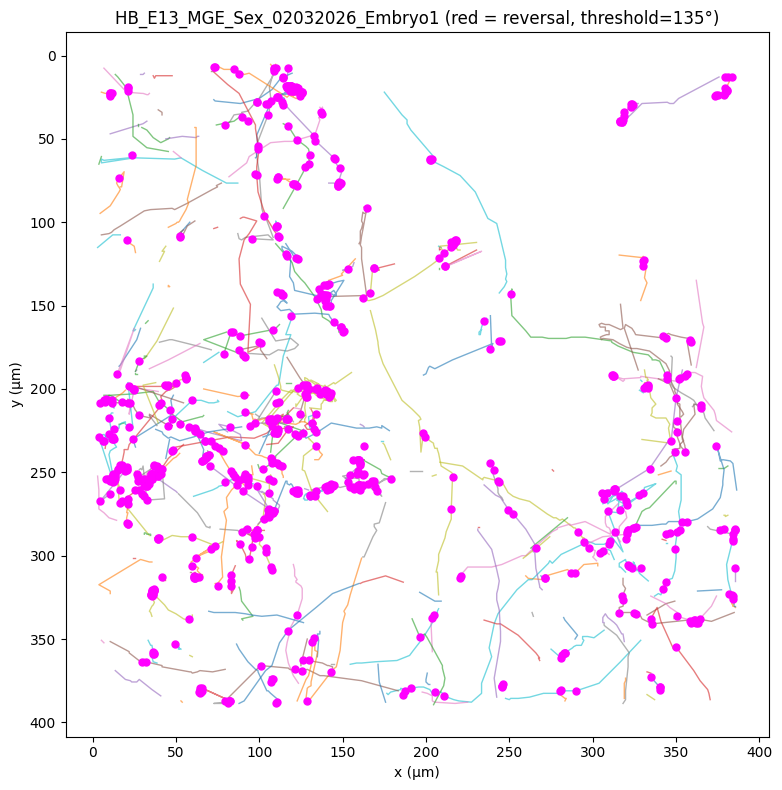

  Tracks: 413, reversal steps: 758

HB_E13_MGE_Sex_02032026_Embryo2
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.80it/s]


    frame 1/129: 20 objects


100%|██████████| 4/4 [00:00<00:00,  7.96it/s]


    frame 2/129: 18 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.30it/s]


    frame 128/129: 24 objects


100%|██████████| 4/4 [00:00<00:00,  8.31it/s]


    frame 129/129: 29 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo2_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


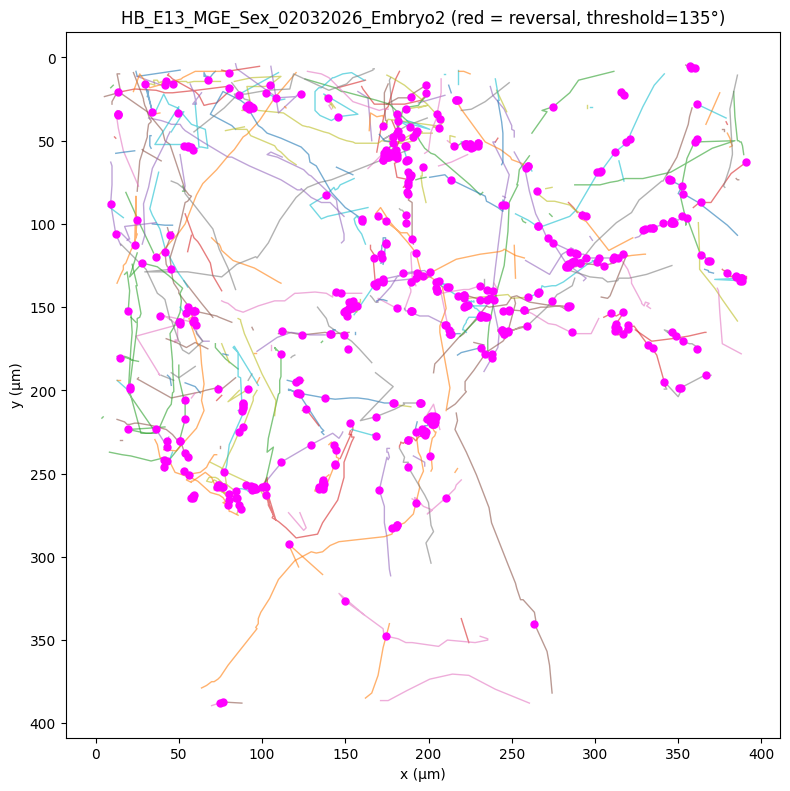

  Tracks: 390, reversal steps: 475

HB_E13_MGE_Sex_02032026_Embryo3
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.78it/s]


    frame 1/129: 29 objects


100%|██████████| 4/4 [00:00<00:00,  8.01it/s]


    frame 2/129: 33 objects


...

100%|██████████| 4/4 [00:00<00:00,  7.13it/s]


    frame 128/129: 37 objects


100%|██████████| 4/4 [00:00<00:00, 10.69it/s]


    frame 129/129: 42 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo3_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


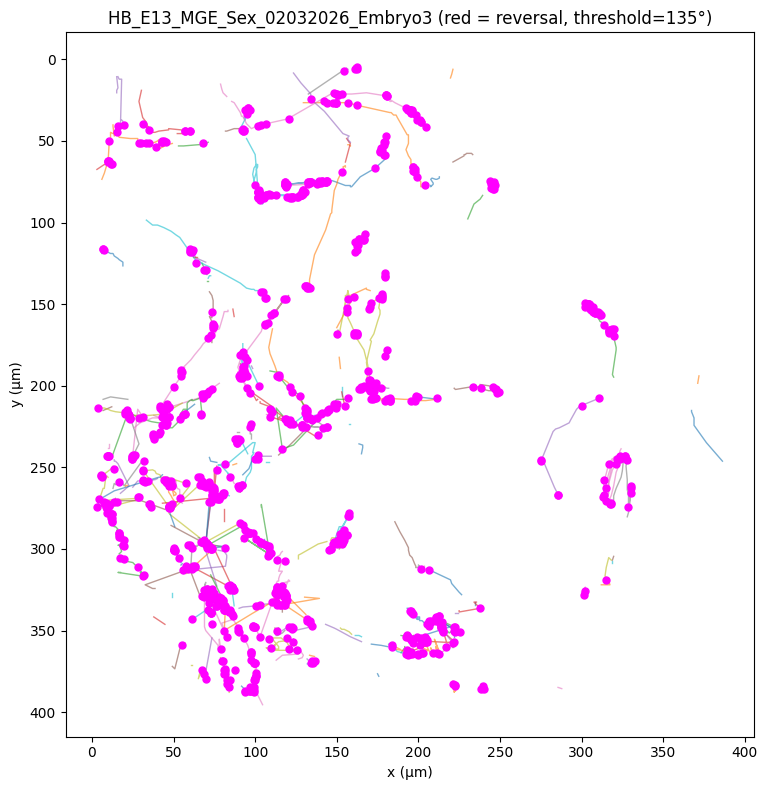

  Tracks: 383, reversal steps: 1092

HB_E13_MGE_Sex_02032026_Embryo4
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.82it/s]


    frame 1/129: 17 objects


100%|██████████| 4/4 [00:00<00:00,  7.94it/s]


    frame 2/129: 15 objects


...

100%|██████████| 4/4 [00:00<00:00,  9.02it/s]


    frame 128/129: 23 objects


100%|██████████| 4/4 [00:00<00:00, 10.66it/s]


    frame 129/129: 20 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo4_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


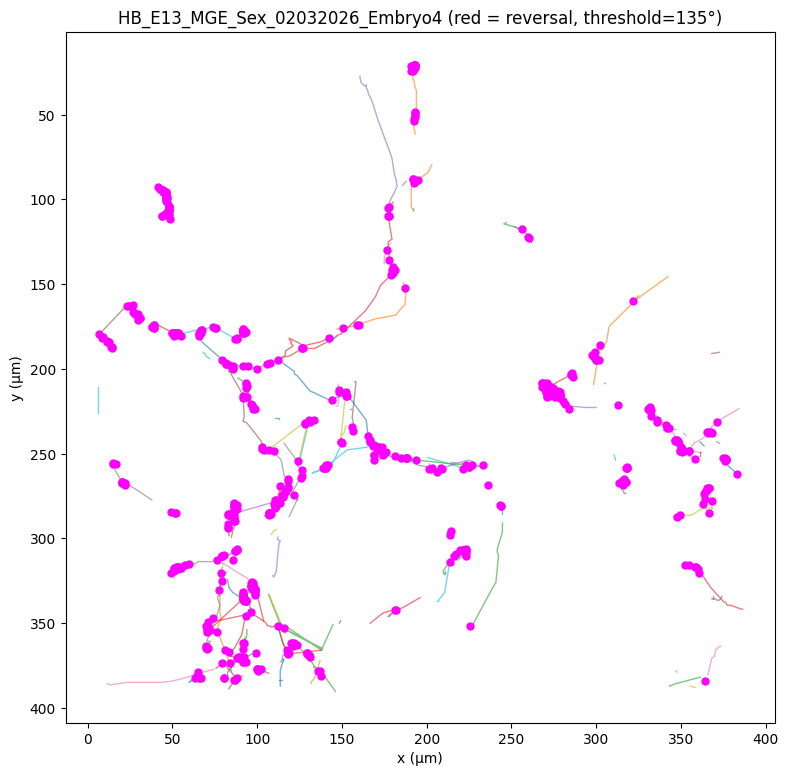

  Tracks: 229, reversal steps: 678

HB_E13_MGE_Sex_02032026_Embryo5
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  5.66it/s]


    frame 1/129: 39 objects


100%|██████████| 4/4 [00:00<00:00,  7.30it/s]


    frame 2/129: 38 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.10it/s]


    frame 128/129: 77 objects


100%|██████████| 4/4 [00:00<00:00, 10.51it/s]


    frame 129/129: 82 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo5_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


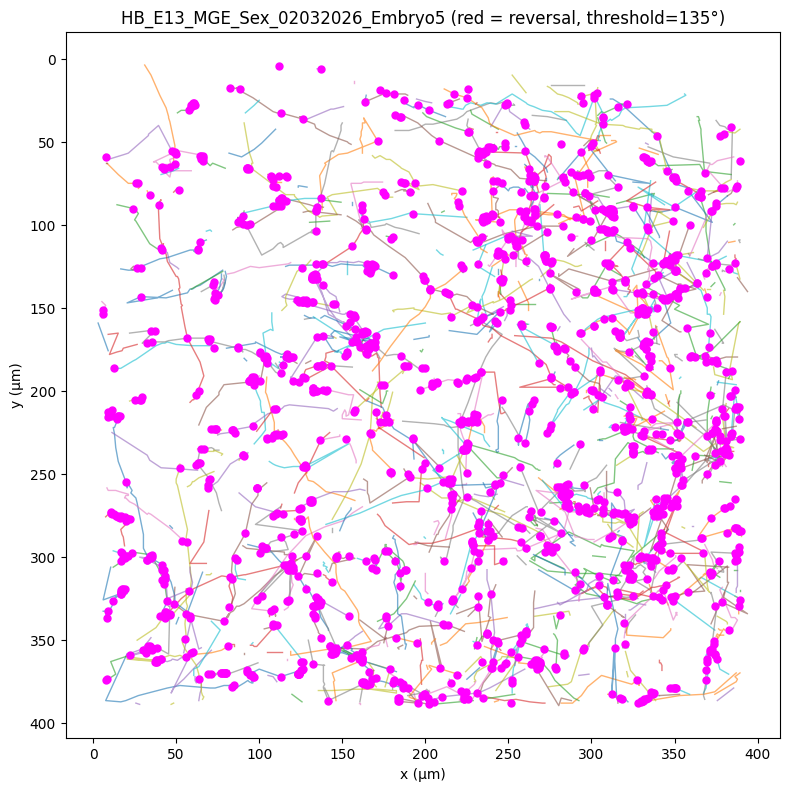

  Tracks: 1053, reversal steps: 1567

HB_E13_MGE_Sex_02032026_Embryo6
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:04<00:00,  1.05s/it]


    frame 1/129: 34 objects


100%|██████████| 4/4 [00:00<00:00, 12.95it/s]


    frame 2/129: 40 objects


...

100%|██████████| 4/4 [00:00<00:00, 11.27it/s]


    frame 128/129: 38 objects


100%|██████████| 4/4 [00:00<00:00,  8.58it/s]


    frame 129/129: 41 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo6_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


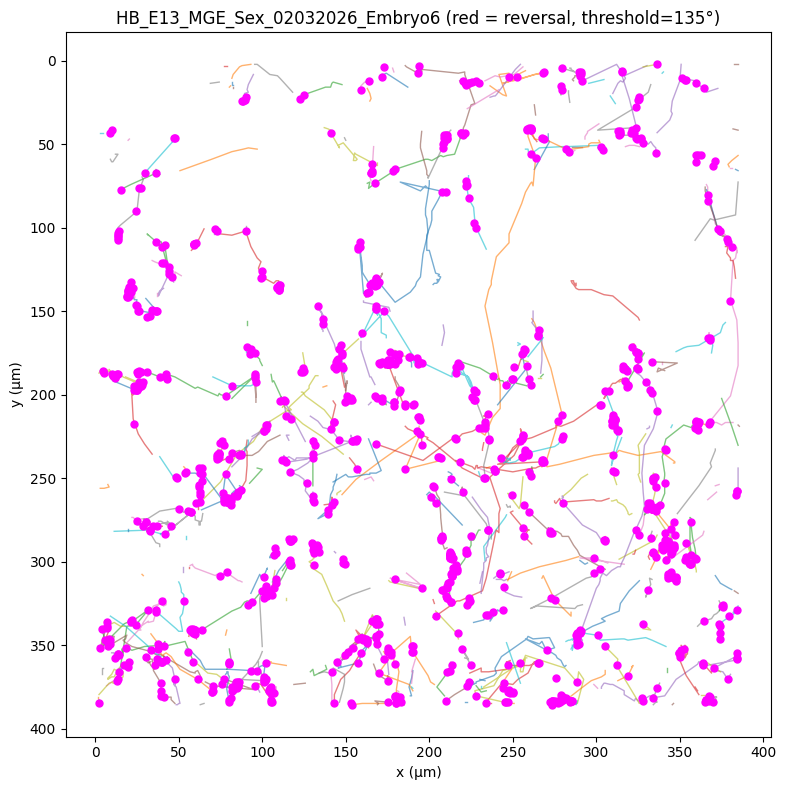

  Tracks: 585, reversal steps: 1076

HB_E13_MGE_Sex_02032026_Embryo7
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.70it/s]


    frame 1/129: 6 objects


100%|██████████| 4/4 [00:00<00:00,  7.87it/s]


    frame 2/129: 5 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.11it/s]


    frame 128/129: 11 objects


100%|██████████| 4/4 [00:00<00:00,  8.96it/s]


    frame 129/129: 11 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo7_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


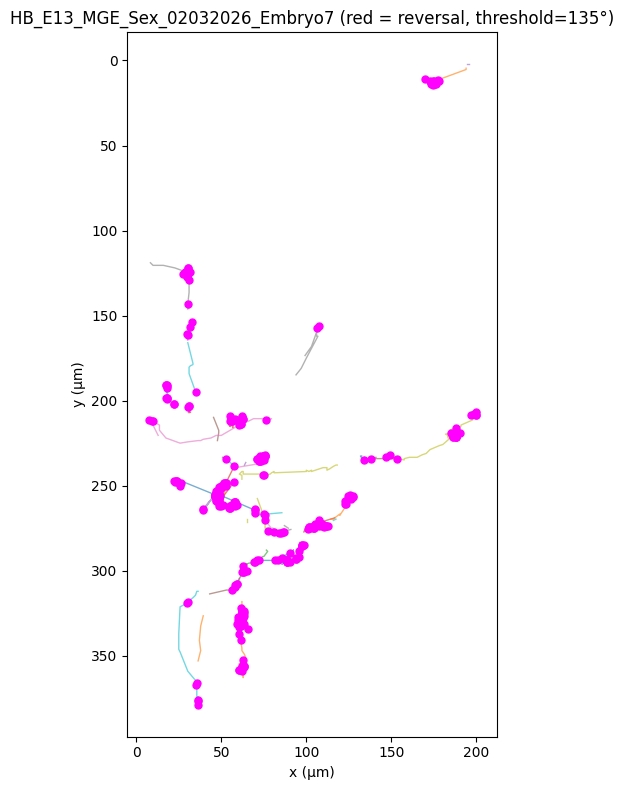

  Tracks: 82, reversal steps: 350

HB_E13_MGE_Sex_02032026_Embryo8
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.49it/s]


    frame 1/129: 13 objects


100%|██████████| 4/4 [00:00<00:00,  7.25it/s]


    frame 2/129: 14 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.69it/s]


    frame 87/129: 14 objects


100%|██████████| 4/4 [00:00<00:00, 10.56it/s]


    frame 88/129: 16 objects


  0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
#Run the batch analysis

all_tracks = []
all_summaries = []
failed_files = []

for input_path in input_paths:
    try:
        tracks_df, track_summary = process_single_movie(
            input_path, model, OUTPUT_DIR,
            MAX_DISPLACEMENT_UM, REVERSAL_ANGLE_THRESHOLD_DEG, n_tiles=N_TILES,
        )
        all_tracks.append(tracks_df)
        all_summaries.append(track_summary)
    except Exception as e:
        print(f"  FAILED: {os.path.basename(input_path)} -> {e}")
        failed_files.append((input_path, str(e)))

print("\n================================")
print("BATCH COMPLETE")
print("================================")
print(f"Processed: {len(all_tracks)} / {len(input_paths)}")
if failed_files:
    print("Failed files:")
    for p, err in failed_files:
        print(" ", os.path.basename(p), "-", err)

In [13]:
#Combine tracks across all movies


combined_tracks_df = pd.concat(all_tracks, ignore_index=True) if all_tracks else pd.DataFrame()
combined_summary_df = pd.concat(all_summaries, ignore_index=True) if all_summaries else pd.DataFrame()

combined_tracks_path = os.path.join(OUTPUT_DIR, "all_movies_tracks_with_angles.csv")
combined_summary_path = os.path.join(OUTPUT_DIR, "all_movies_track_summary.csv")

combined_tracks_df.to_csv(combined_tracks_path, index=False)
combined_summary_df.to_csv(combined_summary_path, index=False)

print("Combined per-detection table:", combined_tracks_path)
print("Combined per-track summary:  ", combined_summary_path)

if not combined_summary_df.empty:
    print("\nReversals per movie:")
    print(combined_summary_df.groupby("movie")["n_reversals"].sum())

Combined per-detection table: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/all_movies_tracks_with_angles.csv
Combined per-track summary:   /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/all_movies_track_summary.csv

Reversals per movie:
movie
HB_E13_MGE_Sex_02032026_Embryo1    37.0
HB_E13_MGE_Sex_02032026_Embryo2    23.0
HB_E13_MGE_Sex_02032026_Embryo3    55.0
Name: n_reversals, dtype: float64
